In [1]:
import numpy as np
import matplotlib.pyplot as plt  
import util_local as ul 
import os
import pickle

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
folder_path = "../3_analysis"  # 替换为你的路径

# 正确方式：仅获取是 .pkl 后缀、且是文件的路径
pickle_files = [
    os.path.join(folder_path, f)
    for f in os.listdir(folder_path)
    if f.endswith(".pkl") and os.path.isfile(os.path.join(folder_path, f))
]


In [3]:
pickle_files

['../3_analysis/MZ029_100uMIPTG_C2_pc_thr_line_profile.pkl',
 '../3_analysis/FS073_C1_pc_thr_line_profile.pkl',
 '../3_analysis/FS073_C2_pc_thr_line_profile.pkl',
 '../3_analysis/MZ029_100uMIPTG_C1_pc_thr_line_profile.pkl',
 '../3_analysis/FS460_C1_pc_thr_line_profile.pkl',
 '../3_analysis/MZ001_20ngCTC_100uMIPTG_C1_pc_thr_line_profile.pkl',
 '../3_analysis/MZ001_20ngCTC_100uMIPTG_C2_pc_thr_line_profile.pkl',
 '../3_analysis/FS463_C1_pc_thr_line_profile.pkl']

In [8]:
####plot code
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

# 高斯函数
def gaussian(x, a, x0, sigma, offset):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + offset

def plot_pickle_data(file_path, y_min=-5, y_max=8, alpha=0.01, line_color='blue', avg_color='red',
                     aligned_x_range=(-15, 15), num_points=150):
    """
    从 pickle 文件读取曲线，按 Gaussian 拟合找到 peak 后对齐并插值统一 x，再绘图与保存。
    """

    with open(file_path, "rb") as file:
        loaded_array = pickle.load(file)

    plt.figure(figsize=(8, 5))
    aligned_x = np.linspace(aligned_x_range[0], aligned_x_range[1], num_points)
    y_stack = []

    for i, ele in enumerate(loaded_array):
        x = np.array(ele[0])
        y = np.array(ele[1])

        if x.size == 0 or y.size == 0 or len(x) < 3:
            continue

        try:
            a_guess = np.max(y) - np.min(y)
            x0_guess = x[np.argmax(y)]
            sigma_guess = 3
            offset_guess = np.min(y)
            popt, _ = curve_fit(gaussian, x, y, p0=[a_guess, x0_guess, sigma_guess, offset_guess])
            x_center = popt[1]
        except Exception as e:
            print(f"Gaussian fit failed for curve {i}, fallback to max position: {e}")
            x_center = x[np.argmax(y)]

        x_shifted = x - x_center

        try:
            f_interp = interp1d(x_shifted, y, kind='linear', bounds_error=False, fill_value=np.nan)
            y_interp = f_interp(aligned_x)
            y_stack.append(y_interp)
            plt.plot(aligned_x, y_interp, linestyle='-', alpha=alpha, color=line_color)
        except Exception as e:
            print(f"Interpolation failed for curve {i}: {e}")
            continue

    #  若有有效曲线，执行绘图 + 保存
    if len(y_stack) > 0:
        y_stack = np.array(y_stack)
        y_mean = np.nanmean(y_stack, axis=0)
        plt.plot(aligned_x, y_mean, linestyle='-', color=avg_color, linewidth=2.5, label='Average Curve')

        # 图像参数
        plt.ylim(y_min, y_max)
        plt.xlabel("Distance from Center Line")
        plt.ylabel("Fluorescence Intensity")
        plt.title(f"Plot from {os.path.basename(file_path)}")
        plt.grid(True)
        plt.legend()

        # 保存图像
        plot_dir = "../line profile figs with avg line"
        os.makedirs(plot_dir, exist_ok=True)
        fig_filename = f"{os.path.basename(file_path)}_fit.png"
        fig_path = os.path.join(plot_dir, fig_filename)
        plt.savefig(fig_path, dpi=300)
        print(f"图像已保存至：{fig_path}")

        # 保存数据
        data_dir = "../3_analysis_narmolized"
        os.makedirs(data_dir, exist_ok=True)
        base_name = os.path.splitext(os.path.basename(file_path))[0]
        np.save(os.path.join(data_dir, f"{base_name}_x_ref.npy"), aligned_x)
        np.save(os.path.join(data_dir, f"{base_name}_y_mean.npy"), y_mean)
        ######不确定是否可以删掉，待验证
        save_dir = "../line profile figs with avg line"
        os.makedirs(save_dir, exist_ok=True)

        fig_filename = f"{os.path.basename(file_path)}_fit.png"
        fig_path = os.path.join(save_dir, fig_filename)

        plt.savefig(fig_path, dpi=300)
        print(f"\n图像已保存至：{fig_path}")

        plt.show()
    else:
        print(f"{file_path} 没有有效曲线，跳过绘图与保存")


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


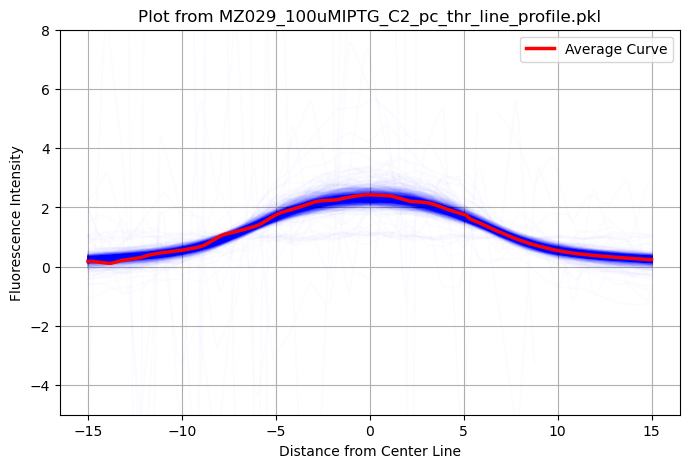

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


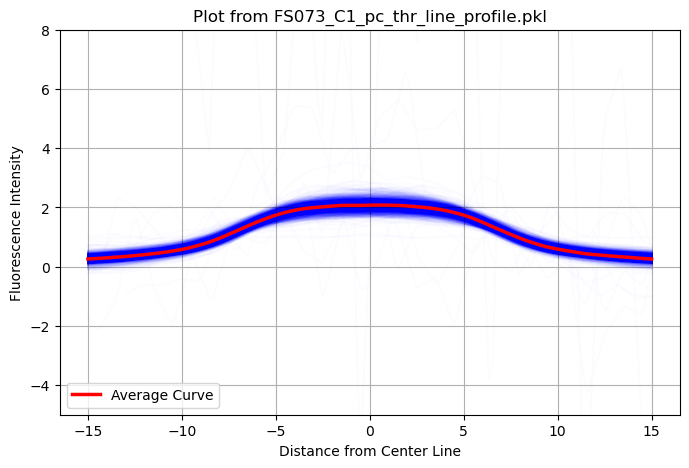

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


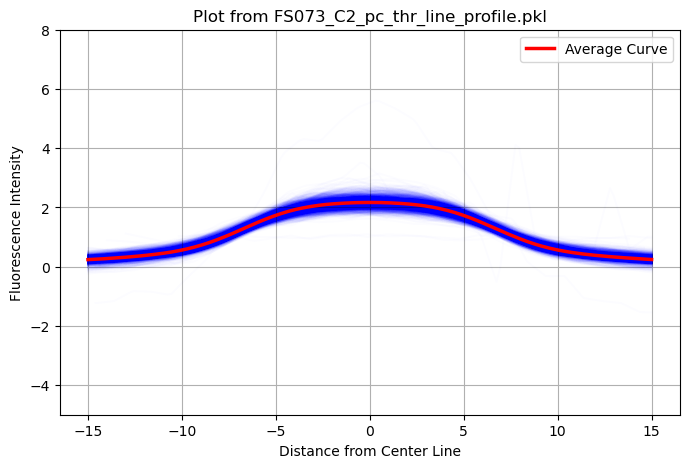

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


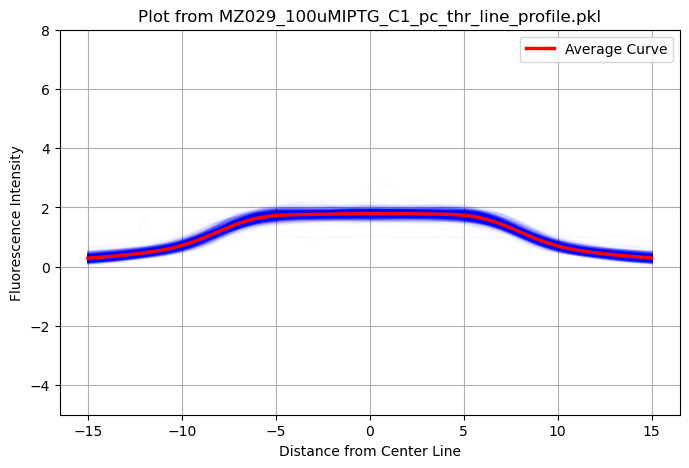

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


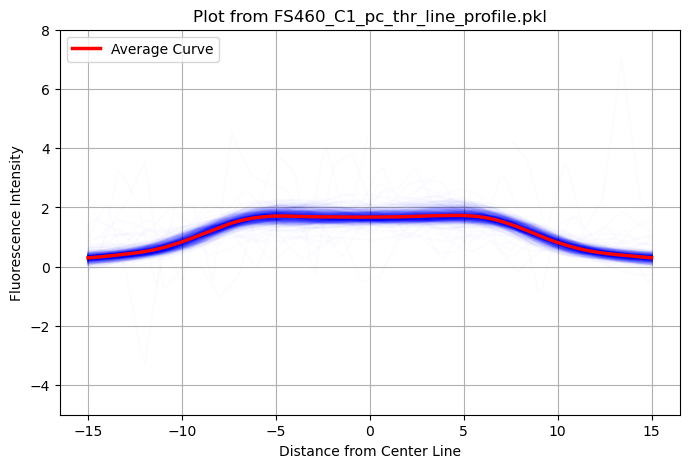

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


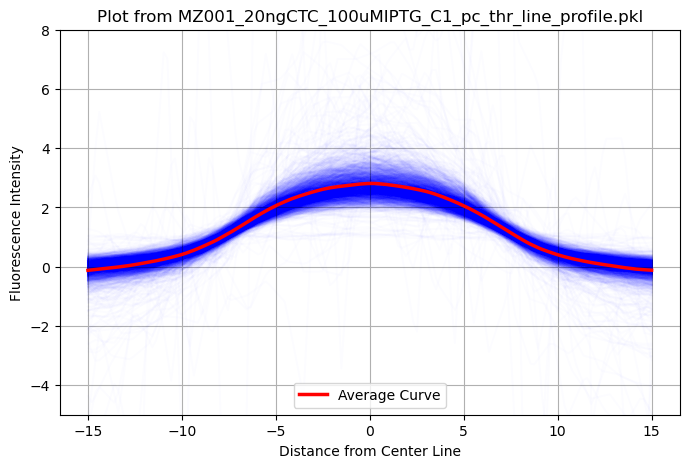

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


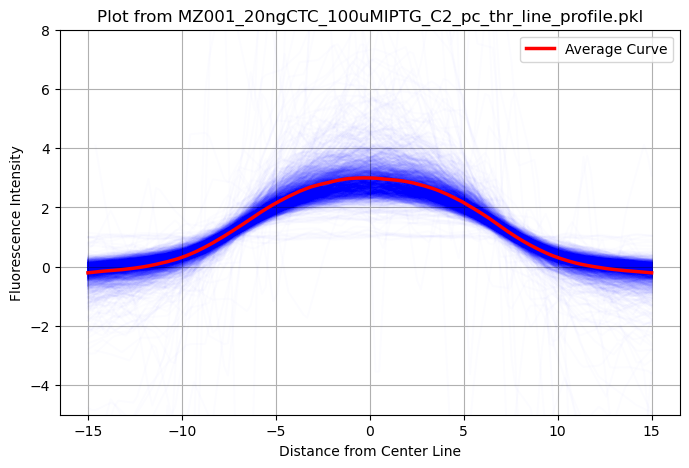

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


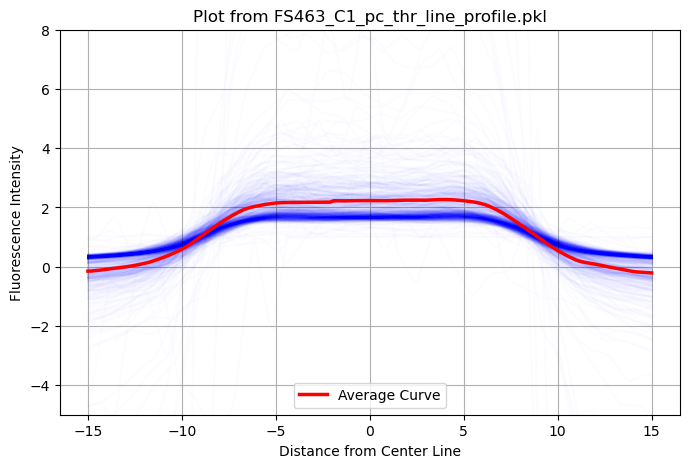

In [9]:
####plot uncombined cells
for file_path in pickle_files:
    # print(f"Processing file: {file_path}")
    plot_pickle_data(file_path)  
    

In [ ]:
# do not use 20260326

random try